In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
# population: 5 features, only 3 matter
X_pop, y_pop, true_coefs = make_regression(n_samples=100000, n_features=5, n_informative=3,
                                           noise=20, coef=True, random_state=7)

features = ['x1', 'x2', 'x3', 'x4', 'x5']
true_coefs = pd.Series(true_coefs, index=features)
print(true_coefs.round(2))

x1     0.00
x2    22.15
x3     2.09
x4     0.00
x5    89.30
dtype: float64


In [3]:
coefs = []
errors = []

# 100 samples of 200 rows
for seed in range(100):
    np.random.seed(seed)
    rows = np.random.choice(len(X_pop), size=200, replace=False)
    X = X_pop[rows]
    y = y_pop[rows]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed)

    model = LinearRegression()
    model.fit(X_train, y_train)

    coefs.append(model.coef_)
    errors.append(mean_squared_error(y_test, model.predict(X_test)))

coefs = pd.DataFrame(coefs, columns=features)
errors = pd.Series(errors)

In [4]:
results = pd.DataFrame({
    'true': true_coefs,
    'average': coefs.mean(),
    'std': coefs.std(),
    'min': coefs.min(),
    'max': coefs.max(),
})
print(results.round(2))

print('x1 positive:', (coefs['x1'] > 0).mean())
print('x3 positive:', (coefs['x3'] > 0).mean())

     true  average   std    min    max
x1   0.00    -0.09  1.53  -4.29   4.66
x2  22.15    22.06  1.53  18.48  25.83
x3   2.09     2.12  1.52  -1.21   5.79
x4   0.00     0.09  1.60  -4.14   3.42
x5  89.30    89.17  1.54  85.22  93.00
x1 positive: 0.48
x3 positive: 0.9


In [5]:
print(errors.describe().round(1))

count    100.0
mean     424.1
std       88.8
min      251.1
25%      363.0
50%      419.4
75%      475.9
max      640.0
dtype: float64


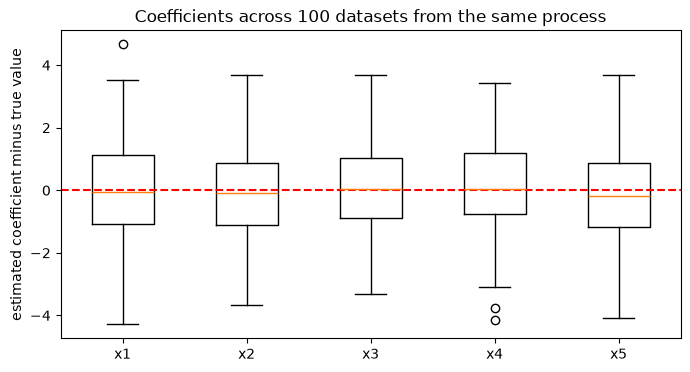

In [6]:
# coef minus true value
plt.figure(figsize=(8, 4))
plt.boxplot((coefs - true_coefs).values)
plt.xticks([1, 2, 3, 4, 5], features)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('estimated coefficient minus true value')
plt.title('Coefficients across 100 datasets from the same process')
plt.savefig('exp1_coefficients.png', dpi=150)
plt.show()

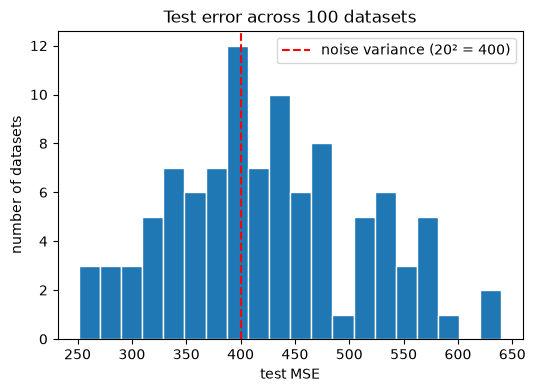

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(errors, bins=20, edgecolor='white')
plt.axvline(400, color='red', linestyle='--', label='noise variance (20² = 400)')
plt.xlabel('test MSE')
plt.ylabel('number of datasets')
plt.title('Test error across 100 datasets')
plt.legend()
plt.savefig('exp1_test_error.png', dpi=150)
plt.show()